In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression

In [3]:
df = sns.load_dataset("titanic")

In [4]:
df.head()

,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
0,0,3,male,22.0,1,0,7.2500,S,Third,man,True,NaN,Southampton,no,False
1,1,1,female,38.0,1,0,71.2833,C,First,woman,False,C,Cherbourg,yes,False
2,1,3,female,26.0,0,0,7.9250,S,Third,woman,False,NaN,Southampton,yes,True
3,1,1,female,35.0,1,0,53.1000,S,First,woman,False,C,Southampton,yes,False
4,0,3,male,35.0,0,0,8.0500,S,Third,man,True,NaN,Southampton,no,True


In [5]:
df.shape

(891, 15)

In [15]:
features = [
    'pclass',
    'sex',
    'age',
    'sibsp',
    'parch',
    'fare',
    'embarked'
]

X = df[features]

y = df["survived"]

In [16]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
    )

In [17]:
numeric_features = [
    'sibsp',
    'parch',
    'fare',
    'age',
    'pclass'
]

categorical_features = [
    'sex',
    'embarked'
]

In [18]:
numeric_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

categorical_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='constant', fill_value='missing')),
    ('onehot', OneHotEncoder(handle_unknown='ignore'))
])

In [19]:
preprocessor = ColumnTransformer(
    transformers=[
        ('num', numeric_transformer, numeric_features),
        ('cat', categorical_transformer, categorical_features)
    ]
)

In [20]:
LogisticModel = Pipeline(
    steps=[
        ('preprocessor', preprocessor),
        ('classifier', LogisticRegression(max_iter=1000))
    ]
)

In [21]:
LogisticModel.fit(X_train, y_train)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='median')),
                                                                  ('scaler',
                                                                   StandardScaler())]),
                                                  ['sibsp', 'parch', 'fare',
                                                   'age', 'pclass']),
                                                 ('cat',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(fill_value='missing',
                                                                                 strategy='constant')),
                                                                  ('onehot',
                                                                   OneHotEncoder(handle_unknown='ignore'))]),
                                                  ['sex', 'embarked'])])),
                ('classifier', LogisticRegression(max_iter=1000))])

In [22]:
Logistic_predictions = LogisticModel.predict(X_test)

In [23]:
print(Logistic_predictions[:20])

[0 0 0 1 1 1 1 0 1 1 0 0 0 0 0 1 0 1 0 0]


In [24]:
Logistic_probabilities = LogisticModel.predict_proba(X_test)

In [26]:
print(Logistic_probabilities[:20])

[[0.89104697 0.10895303]
 [0.78121362 0.21878638]
 [0.86899837 0.13100163]
 [0.11102756 0.88897244]
 [0.25266749 0.74733251]
 [0.06619973 0.93380027]
 [0.31271734 0.68728266]
 [0.91179215 0.08820785]
 [0.2398102  0.7601898 ]
 [0.07589005 0.92410995]
 [0.66787917 0.33212083]
 [0.93241404 0.06758596]
 [0.60911994 0.39088006]
 [0.85451117 0.14548883]
 [0.80522776 0.19477224]
 [0.06068349 0.93931651]
 [0.70110149 0.29889851]
 [0.31267599 0.68732401]
 [0.7585211  0.2414789 ]
 [0.67071802 0.32928198]]


In [29]:
from sklearn.metrics import (
    accuracy_score,
    confusion_matrix,
    classification_report,
    precision_score,
    recall_score,
    f1_score
)

In [30]:
accuracy = accuracy_score(y_test, Logistic_predictions)
print(f"Accuracy: {accuracy}")

Accuracy: 0.8100558659217877


In [32]:
cm = confusion_matrix(
    y_test,
    Logistic_predictions
)
print(cm)

[[90 15]
 [19 55]]


In [33]:
print(
    classification_report(
        y_test,
        Logistic_predictions
    )
)

              precision    recall  f1-score   support

           0       0.83      0.86      0.84       105
           1       0.79      0.74      0.76        74

    accuracy                           0.81       179
   macro avg       0.81      0.80      0.80       179
weighted avg       0.81      0.81      0.81       179



In [34]:
from sklearn.metrics import roc_curve, roc_auc_score

In [36]:
fpr, tpr, thresholds = roc_curve(
    y_test,
    Logistic_probabilities[:, 1]
)

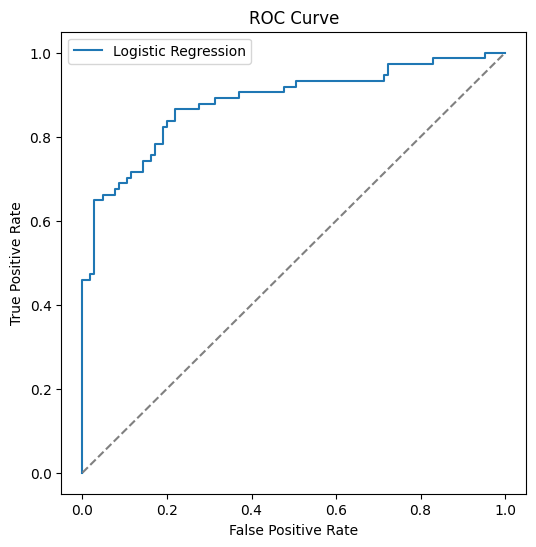

In [37]:
plt.figure(figsize=(6, 6))

plt.plot(
    fpr,
    tpr,
    label='Logistic Regression'
)

plt.plot(
    [0, 1],
    [0, 1],
    linestyle='--',
    color='gray'
)

plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve')
plt.legend()
plt.show()

In [39]:
auc = roc_auc_score(
    y_test,
    Logistic_probabilities[:, 1]
)
print("ROC-AUC: ", auc)

ROC-AUC:  0.8823680823680824
